<a href="https://colab.research.google.com/github/gunjjoshi/optimized-frft/blob/main/frft_feb2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu
Loading Rotated MNIST (0-180°)...
✓ Dataset Ready: 60000 train, 10000 test

✓ FRFT Implementations Ready

✓ All Models Defined

🚀 Starting Training...

Baseline CNN (No FRFT)
Epoch  0: 33.27%
Epoch  2: 52.39%
Epoch  4: 62.13%
Epoch  6: 64.99%
Epoch  8: 69.41%
Epoch  9: 68.65%
✓ Final: 68.65%

Fixed FRFT (OriginalFRFT, p=0.5)
Epoch  0: 45.35%
Epoch  2: 63.60%
Epoch  4: 66.69%
Epoch  6: 70.92%
Epoch  8: 72.25%
Epoch  9: 73.71%
✓ Final: 73.71%

Learnable FRFT (OptimizedFRFT)
Epoch  0: 52.89% | p=0.694
Epoch  2: 66.91% | p=0.701
Epoch  4: 70.27% | p=0.709
Epoch  6: 74.05% | p=0.713
Epoch  8: 76.20% | p=0.714
Epoch  9: 78.33% | p=0.717
✓ Final: 78.33%



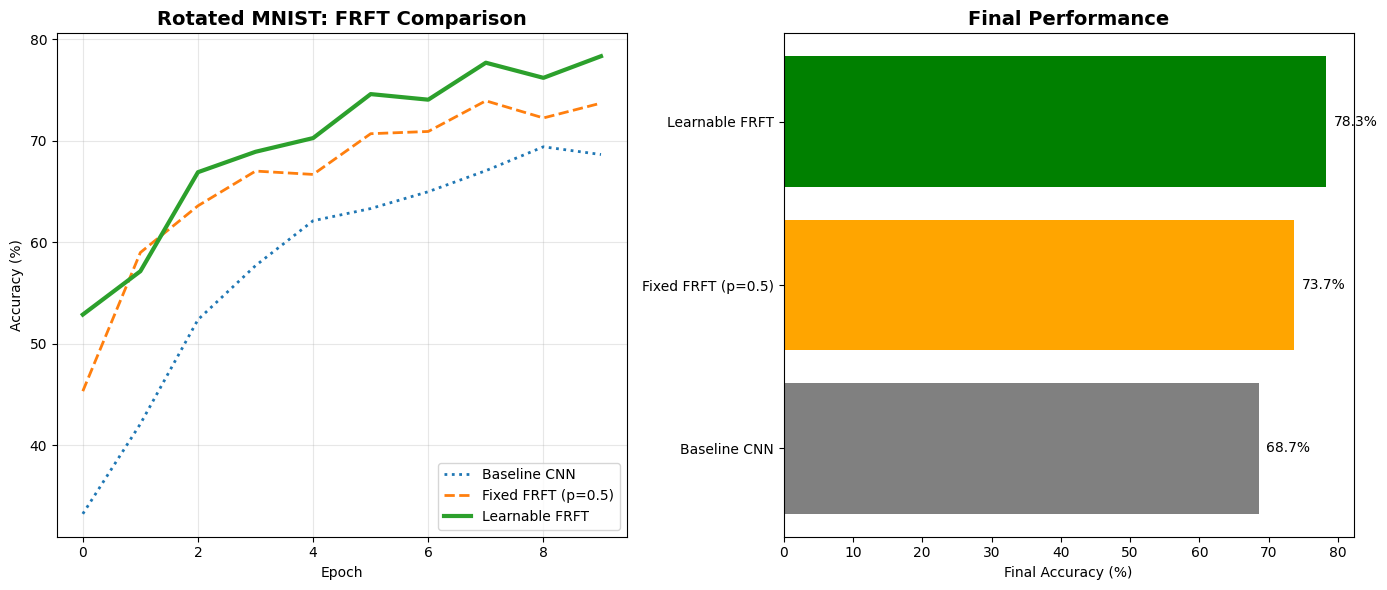


FINAL RESULTS - Rotated MNIST (0-180°)
Baseline CNN                  : 68.65%
Fixed FRFT (p=0.5)            : 73.71%
Learnable FRFT                : 78.33% | Learned p: 0.717

✓ Results saved to 'rotated_mnist_frft_results.png'


In [ ]:
"""
Learnable FRFT: Rotation-Invariant MNIST Classification
Complete comparison: Baseline vs Fixed FRFT vs Learnable FRFT
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import numpy as np
import math, json
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class RotatedMNIST(Dataset):
    """MNIST with random rotations"""
    def __init__(self, train=True, rotation_range=(0, 180)):
        self.base = torchvision.datasets.MNIST(
            root='./data', train=train, download=True
        )
        self.min_rot, self.max_rot = rotation_range
        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        angle = np.random.uniform(self.min_rot, self.max_rot)
        img = TF.rotate(img, angle)
        return self.transform(img), label

print("Loading Rotated MNIST (0-180°)...")
train_ds = RotatedMNIST(train=True)
test_ds = RotatedMNIST(train=False)
trainloader = DataLoader(train_ds, batch_size=128, shuffle=True)
testloader = DataLoader(test_ds, batch_size=128, shuffle=False)
print(f"✓ Dataset Ready: {len(train_ds)} train, {len(test_ds)} test\n")

class OriginalFRFT(nn.Module):
    """Fixed FRFT with buffer (non-learnable) - Original Implementation"""
    def __init__(self, order=0.5):
        super().__init__()
        self.register_buffer('order', torch.tensor([order], dtype=torch.float32))
        self.eigen_cache = {}

    def get_matrix(self, N):
        if N not in self.eigen_cache:
            s = torch.zeros(N, device=device)
            s[1] = 1
            s[-1] = 1
            M = torch.zeros((N, N), device=device)
            dum = s
            for i in range(N):
                M[:, i] = dum
                dum = torch.roll(dum, 1)
            S = M + torch.diag(torch.fft.fft(s).real)

            r = N // 2
            even = 1 - (N % 2)
            P = torch.zeros((N, N), device=device)
            P[0, 0] = 1
            for i in range(1, r - even + 1):
                P[i, i] = P[i, N-i] = 1/math.sqrt(2)
            if even:
                P[r, r] = 1
            for i in range(r+1, N):
                P[i, i] = -1/math.sqrt(2)
                P[i, N-i] = 1/math.sqrt(2)

            CS = P.T @ S @ P
            C2 = CS[:r+1, :r+1]
            S2 = CS[r+1:, r+1:]

            ec, vc = torch.linalg.eigh(C2)
            es, vs = torch.linalg.eigh(S2)

            qvc = torch.vstack([vc, torch.zeros((N-r-1, r+1), device=device)])
            qvs = torch.vstack([torch.zeros((r+1, N-r-1), device=device), vs])

            SC2 = P @ qvc
            SS2 = P @ qvs

            idx_c = torch.argsort(-ec)
            idx_s = torch.argsort(-es)
            SC2 = SC2[:, idx_c]
            SS2 = SS2[:, idx_s]

            if N % 2 == 0:
                Evec = torch.zeros((N, N+1), device=device)
                Evec[:, 0::2] = SC2
                Evec[:, 1:N:2] = torch.hstack([SS2, torch.zeros((N, 1), device=device)])
                Evec = Evec[:, :-1]
            else:
                Evec = torch.zeros((N, N), device=device)
                Evec[:, 0::2] = SC2
                Evec[:, 1:N:2] = SS2

            self.eigen_cache[N] = Evec.to(torch.complex64)

        Evec = self.eigen_cache[N]
        l = torch.arange(N, device=device)
        f = torch.diag(torch.exp(-1j * math.pi/2 * self.order * l))
        return math.sqrt(N) * (Evec @ f @ Evec.T)

    def forward(self, x):
        B, C, H, W = x.shape
        Kh = self.get_matrix(H)
        Kw = self.get_matrix(W)

        x = torch.fft.fftshift(x, dim=(-2, -1)).to(torch.complex64)
        x = torch.einsum('ij,bcjk->bcik', Kh, x)
        x = torch.einsum('bcik,kl->bcil', x, Kw)
        x = torch.fft.fftshift(x, dim=(-2, -1))

        return x.abs()


class OptimizedFRFT(nn.Module):
    """Learnable FRFT with parameter - Optimized Implementation"""
    def __init__(self, initial_order=0.5):
        super().__init__()
        val = 0.0 if abs(initial_order - 0.5) < 0.01 else math.log(initial_order / (1 - initial_order))
        self.raw_order = nn.Parameter(torch.tensor([val], dtype=torch.float32))
        self.eigen_cache = {}

    def get_matrix(self, N, order):
        if N not in self.eigen_cache:
            s = torch.zeros(N, device=device)
            s[1] = 1
            s[-1] = 1
            M = torch.zeros((N, N), device=device)
            dum = s
            for i in range(N):
                M[:, i] = dum
                dum = torch.roll(dum, 1)
            S = M + torch.diag(torch.fft.fft(s).real)

            r = N // 2
            even = 1 - (N % 2)
            P = torch.zeros((N, N), device=device)
            P[0, 0] = 1
            for i in range(1, r - even + 1):
                P[i, i] = P[i, N-i] = 1/math.sqrt(2)
            if even:
                P[r, r] = 1
            for i in range(r+1, N):
                P[i, i] = -1/math.sqrt(2)
                P[i, N-i] = 1/math.sqrt(2)

            CS = P.T @ S @ P
            C2 = CS[:r+1, :r+1]
            S2 = CS[r+1:, r+1:]

            ec, vc = torch.linalg.eigh(C2)
            es, vs = torch.linalg.eigh(S2)

            qvc = torch.vstack([vc, torch.zeros((N-r-1, r+1), device=device)])
            qvs = torch.vstack([torch.zeros((r+1, N-r-1), device=device), vs])

            SC2 = P @ qvc
            SS2 = P @ qvs

            idx_c = torch.argsort(-ec)
            idx_s = torch.argsort(-es)
            SC2 = SC2[:, idx_c]
            SS2 = SS2[:, idx_s]

            if N % 2 == 0:
                Evec = torch.zeros((N, N+1), device=device)
                Evec[:, 0::2] = SC2
                Evec[:, 1:N:2] = torch.hstack([SS2, torch.zeros((N, 1), device=device)])
                Evec = Evec[:, :-1]
            else:
                Evec = torch.zeros((N, N), device=device)
                Evec[:, 0::2] = SC2
                Evec[:, 1:N:2] = SS2

            self.eigen_cache[N] = Evec.to(torch.complex64)

        Evec = self.eigen_cache[N]
        l = torch.arange(N, device=device)
        f = torch.diag(torch.exp(-1j * math.pi/2 * order * l))
        return math.sqrt(N) * (Evec @ f @ Evec.T)

    def forward(self, x):
        B, C, H, W = x.shape
        order = torch.sigmoid(self.raw_order)
        Kh = self.get_matrix(H, order)
        Kw = self.get_matrix(W, order)

        x = torch.fft.fftshift(x, dim=(-2, -1)).to(torch.complex64)
        x = torch.einsum('ij,bcjk->bcik', Kh, x)
        x = torch.einsum('bcik,kl->bcil', x, Kw)
        x = torch.fft.fftshift(x, dim=(-2, -1))

        return x.abs()

print("✓ FRFT Implementations Ready\n")

class BaselineCNN(nn.Module):
    """Standard CNN - No FRFT"""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        return self.fc(self.features(x).view(x.size(0), -1))


class FixedFRFTNet(nn.Module):
    """CNN with Fixed FRFT (OriginalFRFT, p=0.5)"""
    def __init__(self):
        super().__init__()
        self.frft = OriginalFRFT(order=0.5)
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.frft(x)
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))


class LearnableFRFTNet(nn.Module):
    """CNN with Learnable FRFT (OptimizedFRFT, learns p)"""
    def __init__(self):
        super().__init__()
        self.frft = OptimizedFRFT(initial_order=0.5)
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.frft(x)
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))

print("✓ All Models Defined\n")

def train_model(model, name, epochs=10):
    print(f"{'='*50}\n{name}\n{'='*50}")
    model = model.to(device)

    frft_params = [p for n, p in model.named_parameters() if 'raw_order' in n]
    other_params = [p for n, p in model.named_parameters() if 'raw_order' not in n]

    if frft_params:
        optimizer = optim.Adam([
            {'params': other_params, 'lr': 0.001},
            {'params': frft_params, 'lr': 0.01}  # Higher LR for order parameter
        ])
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    criterion = nn.CrossEntropyLoss()
    history = {'acc': [], 'orders': []}

    for epoch in range(epochs):
        model.train()
        for x, y in trainloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            criterion(model(x), y).backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in testloader:
                x, y = x.to(device), y.to(device)
                _, pred = torch.max(model(x), 1)
                total += y.size(0)
                correct += (pred == y).sum().item()

        acc = 100 * correct / total
        history['acc'].append(acc)

        orders = [torch.sigmoid(p).item() for n, p in model.named_parameters() if 'raw_order' in n]
        history['orders'].append(orders)

        if epoch % 2 == 0 or epoch == epochs - 1:
            order_str = f" | p={orders[0]:.3f}" if orders else ""
            print(f"Epoch {epoch:2d}: {acc:.2f}%{order_str}")

    print(f"✓ Final: {history['acc'][-1]:.2f}%\n")
    return history

print("🚀 Starting Training...\n")
results = {}
results['Baseline CNN'] = train_model(BaselineCNN(), 'Baseline CNN (No FRFT)')
results['Fixed FRFT (p=0.5)'] = train_model(FixedFRFTNet(), 'Fixed FRFT (OriginalFRFT, p=0.5)')
results['Learnable FRFT'] = train_model(LearnableFRFTNet(), 'Learnable FRFT (OptimizedFRFT)')

with open('rotated_mnist_frft_results.json', 'w') as f:
    json.dump({k: {'acc': v['acc'], 'orders': v['orders']} for k, v in results.items()}, f, indent=2)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for name, hist in results.items():
    style = ':' if 'Baseline' in name else ('--' if 'Fixed' in name else '-')
    width = 3 if 'Learnable' in name else 2
    plt.plot(hist['acc'], label=name, linestyle=style, linewidth=width)

plt.title('Rotated MNIST: FRFT Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
names = list(results.keys())
final_accs = [results[n]['acc'][-1] for n in names]
colors = ['gray', 'orange', 'green']
bars = plt.barh(names, final_accs, color=colors)
plt.xlabel('Final Accuracy (%)')
plt.title('Final Performance', fontsize=14, fontweight='bold')
for i, (bar, acc) in enumerate(zip(bars, final_accs)):
    plt.text(acc + 1, i, f'{acc:.1f}%', va='center')

plt.tight_layout()
plt.savefig('rotated_mnist_frft_results.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("FINAL RESULTS - Rotated MNIST (0-180°)")
print("="*70)
for name in names:
    acc = results[name]['acc'][-1]
    orders = results[name]['orders'][-1]
    order_str = f" | Learned p: {orders[0]:.3f}" if orders else ""
    print(f"{name:30s}: {acc:5.2f}%{order_str}")
print("="*70)
print("\n✓ Results saved to 'rotated_mnist_frft_results.png'")


In [ ]:
from google.colab import files
files.upload()

In [ ]:
"""
Speech Emotion Recognition with Learnable FRFT
5-Way Comparison: Baseline, Fixed, Single Learnable, Multi-Head, Deep Stacked
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import math, os, json
from torch.utils.data import Dataset, DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
os.makedirs('./data', exist_ok=True)

# ============================================================================
# DATA GENERATION (FIXED)
# ============================================================================

def generate_emotional_speech(N=2000, length=64):
    """
    Generate synthetic emotional speech patterns.
    - Class 0 (Happy): Smooth sinusoidal modulation (low freq chirp)
    - Class 1 (Angry): Sharp, rapid modulation (high freq chirp)
    """
    X, Y = [], []

    for i in range(N):
        label = i % 2

        if label == 0:  # Happy - Smooth prosody
            chirp_rate = 0.3
            base_freq = 2.0
        else:  # Angry - Sharp prosody
            chirp_rate = 0.8
            base_freq = 3.0

        # Create 2D time-frequency pattern
        grid = torch.arange(length).float()
        m, n = torch.meshgrid(grid, grid, indexing='ij')

        # Chirp pattern
        angle = chirp_rate * math.pi / 2
        cot_a = 1.0 / math.tan(angle) if angle != 0 else 1e6
        pattern = torch.cos(math.pi * cot_a * (m**2 + n**2) / length)

        # Add harmonic structure (FIXED: proper broadcasting)
        harmonic_1d = torch.sin(2 * math.pi * base_freq * grid / length)
        harmonic = harmonic_1d.unsqueeze(1).repeat(1, length)

        # Combine with noise
        noise = 0.3 * torch.randn(length, length)
        signal = 0.5 * pattern + 0.3 * harmonic + noise

        X.append(signal.unsqueeze(0))
        Y.append(label)

    return TensorDataset(torch.stack(X), torch.tensor(Y))

print("Generating Emotional Speech Dataset...")
train_ds = generate_emotional_speech(N=2000, length=64)
test_ds = generate_emotional_speech(N=500, length=64)
trainloader = DataLoader(train_ds, batch_size=64, shuffle=True)
testloader = DataLoader(test_ds, batch_size=64, shuffle=False)
print(f"✓ Dataset Ready: {len(train_ds)} train, {len(test_ds)} test")

# ============================================================================
# FRFT IMPLEMENTATIONS
# ============================================================================

class OriginalFRFT(nn.Module):
    """Fixed FRFT with buffer (non-learnable)"""
    def __init__(self, order=0.5):
        super().__init__()
        self.register_buffer('order', torch.tensor([order], dtype=torch.float32))
        self.eigen_cache = {}

    def get_matrix(self, N):
        if N not in self.eigen_cache:
            # Pei sampling method
            s = torch.cat([torch.tensor([0, 1], device=device),
                          torch.zeros(N-2, device=device),
                          torch.tensor([1], device=device)])
            M = torch.zeros((N, N), device=device)
            dum = s
            for i in range(N):
                M[:, i] = dum
                dum = torch.roll(dum, 1)
            S = M + torch.diag(torch.fft.fft(s).real)

            # Eigen decomposition
            r = N // 2
            even = 1 - (N % 2)
            P = torch.zeros((N, N), device=device)
            P[0, 0] = 1
            for i in range(1, r - even + 1):
                P[i, i] = P[i, N-i] = 1/math.sqrt(2)
            if even:
                P[r, r] = 1
            for i in range(r+1, N):
                P[i, i] = -1/math.sqrt(2)
                P[i, N-i] = 1/math.sqrt(2)

            CS = P.T @ S @ P
            C2 = CS[:r+1, :r+1]
            S2 = CS[r+1:, r+1:]

            ec, vc = torch.linalg.eigh(C2)
            es, vs = torch.linalg.eigh(S2)

            qvc = torch.vstack([vc, torch.zeros((N-r-1, r+1), device=device)])
            qvs = torch.vstack([torch.zeros((r+1, N-r-1), device=device), vs])

            SC2 = P @ qvc
            SS2 = P @ qvs

            idx_c = torch.argsort(-ec)
            idx_s = torch.argsort(-es)
            SC2 = SC2[:, idx_c]
            SS2 = SS2[:, idx_s]

            if N % 2 == 0:
                Evec = torch.zeros((N, N+1), device=device)
                Evec[:, 0::2] = SC2
                Evec[:, 1:N:2] = torch.hstack([SS2, torch.zeros((N, 1), device=device)])
                Evec = Evec[:, :-1]
            else:
                Evec = torch.zeros((N, N), device=device)
                Evec[:, 0::2] = SC2
                Evec[:, 1:N:2] = SS2

            self.eigen_cache[N] = Evec.to(torch.complex64)

        Evec = self.eigen_cache[N]
        l = torch.arange(N, device=device)
        f = torch.diag(torch.exp(-1j * math.pi/2 * self.order * l))
        return math.sqrt(N) * (Evec @ f @ Evec.T)

    def forward(self, x):
        B, C, H, W = x.shape
        Kh = self.get_matrix(H)
        Kw = self.get_matrix(W)

        x = torch.fft.fftshift(x, dim=(-2, -1)).to(torch.complex64)
        x = torch.einsum('ij,bcjk->bcik', Kh, x)
        x = torch.einsum('bcik,kl->bcil', x, Kw)
        x = torch.fft.fftshift(x, dim=(-2, -1))
        return x.abs() / math.sqrt(H * W)


class OptimizedFRFT(nn.Module):
    """Learnable FRFT with parameter"""
    def __init__(self, initial_order=0.5):
        super().__init__()
        val = 0.0 if abs(initial_order - 0.5) < 0.01 else math.log(initial_order / (1 - initial_order))
        self.raw_order = nn.Parameter(torch.tensor([val], dtype=torch.float32))
        self.eigen_cache = {}

    def get_matrix(self, N, order):
        if N not in self.eigen_cache:
            # Same as OriginalFRFT
            s = torch.cat([torch.tensor([0, 1], device=device),
                          torch.zeros(N-2, device=device),
                          torch.tensor([1], device=device)])
            M = torch.zeros((N, N), device=device)
            dum = s
            for i in range(N):
                M[:, i] = dum
                dum = torch.roll(dum, 1)
            S = M + torch.diag(torch.fft.fft(s).real)

            r = N // 2
            even = 1 - (N % 2)
            P = torch.zeros((N, N), device=device)
            P[0, 0] = 1
            for i in range(1, r - even + 1):
                P[i, i] = P[i, N-i] = 1/math.sqrt(2)
            if even:
                P[r, r] = 1
            for i in range(r+1, N):
                P[i, i] = -1/math.sqrt(2)
                P[i, N-i] = 1/math.sqrt(2)

            CS = P.T @ S @ P
            C2 = CS[:r+1, :r+1]
            S2 = CS[r+1:, r+1:]

            ec, vc = torch.linalg.eigh(C2)
            es, vs = torch.linalg.eigh(S2)

            qvc = torch.vstack([vc, torch.zeros((N-r-1, r+1), device=device)])
            qvs = torch.vstack([torch.zeros((r+1, N-r-1), device=device), vs])

            SC2 = P @ qvc
            SS2 = P @ qvs

            idx_c = torch.argsort(-ec)
            idx_s = torch.argsort(-es)
            SC2 = SC2[:, idx_c]
            SS2 = SS2[:, idx_s]

            if N % 2 == 0:
                Evec = torch.zeros((N, N+1), device=device)
                Evec[:, 0::2] = SC2
                Evec[:, 1:N:2] = torch.hstack([SS2, torch.zeros((N, 1), device=device)])
                Evec = Evec[:, :-1]
            else:
                Evec = torch.zeros((N, N), device=device)
                Evec[:, 0::2] = SC2
                Evec[:, 1:N:2] = SS2

            self.eigen_cache[N] = Evec.to(torch.complex64)

        Evec = self.eigen_cache[N]
        l = torch.arange(N, device=device)
        f = torch.diag(torch.exp(-1j * math.pi/2 * order * l))
        return math.sqrt(N) * (Evec @ f @ Evec.T)

    def forward(self, x):
        B, C, H, W = x.shape
        order = torch.sigmoid(self.raw_order)
        Kh = self.get_matrix(H, order)
        Kw = self.get_matrix(W, order)

        x = torch.fft.fftshift(x, dim=(-2, -1)).to(torch.complex64)
        x = torch.einsum('ij,bcjk->bcik', Kh, x)
        x = torch.einsum('bcik,kl->bcil', x, Kw)
        x = torch.fft.fftshift(x, dim=(-2, -1))
        return x.abs() / math.sqrt(H * W)

print("✓ FRFT Core Implementations Ready")

# ============================================================================
# MODEL ARCHITECTURES
# ============================================================================

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        x = self.features(x)
        return self.fc(x.view(x.size(0), -1))


class FixedFRFTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.frft = OriginalFRFT(order=0.5)
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        x = self.frft(x)
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))


class SingleLearnableFRFT(nn.Module):
    def __init__(self):
        super().__init__()
        self.frft = OptimizedFRFT(initial_order=0.5)
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        x = self.frft(x)
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))


class MultiHeadFRFT(nn.Module):
    def __init__(self, heads=4):
        super().__init__()
        self.heads = nn.ModuleList([
            OptimizedFRFT(initial_order=p)
            for p in np.linspace(0.2, 0.8, heads)
        ])
        self.fusion = nn.Conv2d(heads, 32, 1)
        self.conv = nn.Sequential(
            nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        outs = [head(x) for head in self.heads]
        x = torch.cat(outs, dim=1)
        x = self.fusion(x)
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))


class DeepStackedFRFT(nn.Module):
    def __init__(self):
        super().__init__()
        self.frft1 = OptimizedFRFT(initial_order=0.3)
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU()
        )
        self.frft2 = OptimizedFRFT(initial_order=0.7)
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        x = self.frft1(x)
        x = self.conv1(x)
        x = self.frft2(x)
        x = self.conv2(x)
        return self.fc(x.view(x.size(0), -1))

print("✓ All 5 Model Architectures Defined")

# ============================================================================
# TRAINING
# ============================================================================

def train_model(model, name, epochs=20):
    print(f"\n{'='*50}\nTraining: {name}\n{'='*50}")
    model = model.to(device)

    # Separate learning rates for FRFT parameters
    frft_params = [p for n, p in model.named_parameters() if 'raw_order' in n]
    other_params = [p for n, p in model.named_parameters() if 'raw_order' not in n]

    if frft_params:
        optimizer = optim.Adam([
            {'params': other_params, 'lr': 0.001},
            {'params': frft_params, 'lr': 0.02}
        ])
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    criterion = nn.CrossEntropyLoss()
    history = {'acc': [], 'loss': [], 'orders': []}

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for x, y in trainloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Evaluate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in testloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                _, pred = torch.max(out, 1)
                total += y.size(0)
                correct += (pred == y).sum().item()

        acc = 100 * correct / total
        avg_loss = train_loss / len(trainloader)
        history['acc'].append(acc)
        history['loss'].append(avg_loss)

        # Track learned orders
        orders = []
        for n, p in model.named_parameters():
            if 'raw_order' in n:
                orders.append(torch.sigmoid(p).item())
        history['orders'].append(orders)

        if epoch % 5 == 0 or epoch == epochs - 1:
            order_str = f" | Orders: {[f'{o:.3f}' for o in orders]}" if orders else ""
            print(f"Epoch {epoch:2d}: Loss={avg_loss:.4f}, Acc={acc:.2f}%{order_str}")

    print(f"\n✓ Final Accuracy: {history['acc'][-1]:.2f}%")
    return history

# Run all experiments
results = {}
results['Baseline CNN'] = train_model(BaselineCNN(), 'Baseline CNN')
results['Fixed FRFT (p=0.5)'] = train_model(FixedFRFTNet(), 'Fixed FRFT (p=0.5)')
results['Single Learnable FRFT'] = train_model(SingleLearnableFRFT(), 'Single Learnable FRFT')
results['Multi-Head FRFT'] = train_model(MultiHeadFRFT(heads=4), 'Multi-Head FRFT (4 heads)')
results['Deep Stacked FRFT'] = train_model(DeepStackedFRFT(), 'Deep Stacked FRFT')

# Save results
with open('emotion_results.json', 'w') as f:
    json.dump({k: {'acc': v['acc'], 'orders': v['orders']} for k, v in results.items()}, f, indent=2)

# ============================================================================
# VISUALIZATION
# ============================================================================

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for name, hist in results.items():
    style = ':' if 'Baseline' in name else ('--' if 'Fixed' in name else '-')
    width = 3 if 'Stacked' in name or 'Multi' in name else 2
    plt.plot(hist['acc'], label=name, linestyle=style, linewidth=width)

plt.title('Speech Emotion Recognition: Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Plot final accuracies
plt.subplot(1, 2, 2)
names = list(results.keys())
final_accs = [results[n]['acc'][-1] for n in names]
colors = ['gray', 'orange', 'lightblue', 'green', 'darkgreen']
bars = plt.barh(names, final_accs, color=colors)
plt.xlabel('Final Accuracy (%)')
plt.title('Final Performance Comparison', fontsize=14, fontweight='bold')
plt.xlim(0, 100)
for i, (bar, acc) in enumerate(zip(bars, final_accs)):
    plt.text(acc + 1, i, f'{acc:.1f}%', va='center')

plt.tight_layout()
plt.savefig('emotion_recognition_results.png', dpi=200, bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
for name in names:
    acc = results[name]['acc'][-1]
    orders = results[name]['orders'][-1]
    order_str = f" | Learned p: {orders}" if orders else ""
    print(f"{name:30s}: {acc:5.2f}%{order_str}")
print("="*60)


Device: cpu
Generating Emotional Speech Dataset...
✓ Dataset Ready: 2000 train, 500 test
✓ FRFT Core Implementations Ready
✓ All 5 Model Architectures Defined

Training: Baseline CNN
Epoch  0: Loss=0.6119, Acc=100.00%
Epoch  5: Loss=0.0027, Acc=100.00%
Epoch 10: Loss=0.0005, Acc=100.00%
Epoch 15: Loss=0.0002, Acc=100.00%
Epoch 19: Loss=0.0001, Acc=100.00%

✓ Final Accuracy: 100.00%

Training: Fixed FRFT (p=0.5)


RuntimeError: The expanded size of the tensor (64) must match the existing size (65) at non-singleton dimension 0.  Target sizes: [64].  Tensor sizes: [65]

In [ ]:
def generate_emotional_speech(N=2000, length=64):
    """
    Generate synthetic emotional speech patterns.
    - Class 0 (Happy): Smooth sinusoidal modulation (low freq chirp)
    - Class 1 (Angry): Sharp, rapid modulation (high freq chirp)
    """
    X, Y = [], []
    t = torch.linspace(0, 1, length)

    for i in range(N):
        label = i % 2

        if label == 0:  # Happy - Smooth prosody
            # Low chirp rate (p ~ 0.3)
            chirp_rate = 0.3
            base_freq = 2.0
        else:  # Angry - Sharp prosody
            # High chirp rate (p ~ 0.8)
            chirp_rate = 0.8
            base_freq = 3.0

        # Create 2D time-frequency pattern
        grid = torch.arange(length).float()
        m, n = torch.meshgrid(grid, grid, indexing='ij')

        # Chirp pattern: cos(pi * cot(alpha) * (m^2 + n^2))
        angle = chirp_rate * math.pi / 2
        cot_a = 1.0 / math.tan(angle) if angle != 0 else 1e6

        pattern = torch.cos(math.pi * cot_a * (m**2 + n**2) / length)

        # Add harmonic structure (speech formants)
        harmonic = torch.sin(2 * math.pi * base_freq * m / length)

        # Combine with noise
        noise = 0.3 * torch.randn(length, length)
        signal = 0.5 * pattern + 0.3 * harmonic.unsqueeze(1).expand(-1, length) + noise

        X.append(signal.unsqueeze(0))
        Y.append(label)

    return torch.utils.data.TensorDataset(torch.stack(X), torch.tensor(Y))

print("Generating Emotional Speech Dataset...")
train_ds = generate_emotional_speech(N=2000, length=64)
test_ds = generate_emotional_speech(N=500, length=64)
trainloader = DataLoader(train_ds, batch_size=64, shuffle=True)
testloader = DataLoader(test_ds, batch_size=64, shuffle=False)
print(f"✓ Dataset Ready: {len(train_ds)} train, {len(test_ds)} test")

Generating Emotional Speech Dataset...


RuntimeError: expand(torch.FloatTensor{[64, 1, 64]}, size=[-1, 64]): the number of sizes provided (2) must be greater or equal to the number of dimensions in the tensor (3)